## imports

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "raw" / "CMAPSS"

TRAIN_FILE = DATA_DIR / "train_FD001.txt"
TEST_FILE = DATA_DIR / "test_FD001.txt"
RUL_FILE = DATA_DIR / "RUL_FD001.txt"

print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)

Project root: d:\industrial-predictive-maintenance
Data directory: d:\industrial-predictive-maintenance\data\raw\CMAPSS


In [3]:
print(TRAIN_FILE.exists())
print(TEST_FILE.exists())
print(RUL_FILE.exists())

True
True
True


### Understand the raw file

In [6]:
columns = [
    "engine_id",
    "cycle",
    "setting_1",
    "setting_2",
    "setting_3",
    *[f"sensor_{i}" for i in range(1, 22)]
]

In [7]:
train_df = pd.read_csv(
    TRAIN_FILE,
    sep=r"\s+",
    header=None,
    names=columns
)

train_df.head()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [9]:
train_df.shape

(20631, 26)

In [10]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   engine_id  20631 non-null  int64  
 1   cycle      20631 non-null  int64  
 2   setting_1  20631 non-null  float64
 3   setting_2  20631 non-null  float64
 4   setting_3  20631 non-null  float64
 5   sensor_1   20631 non-null  float64
 6   sensor_2   20631 non-null  float64
 7   sensor_3   20631 non-null  float64
 8   sensor_4   20631 non-null  float64
 9   sensor_5   20631 non-null  float64
 10  sensor_6   20631 non-null  float64
 11  sensor_7   20631 non-null  float64
 12  sensor_8   20631 non-null  float64
 13  sensor_9   20631 non-null  float64
 14  sensor_10  20631 non-null  float64
 15  sensor_11  20631 non-null  float64
 16  sensor_12  20631 non-null  float64
 17  sensor_13  20631 non-null  float64
 18  sensor_14  20631 non-null  float64
 19  sensor_15  20631 non-null  float64
 20  sensor_16  20631 

___

### investigate the dataset

In [15]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
engine_id,20631.0,51.506568,2.922763e+01,1.0000,26.0000,52.0000,77.0000,100.0000
cycle,20631.0,108.807862,6.888099e+01,1.0000,52.0000,104.0000,156.0000,362.0000
setting_1,20631.0,-0.000009,2.187313e-03,-0.0087,-0.0015,0.0000,0.0015,0.0087
setting_2,20631.0,0.000002,2.930621e-04,-0.0006,-0.0002,0.0000,0.0003,0.0006
setting_3,20631.0,100.000000,0.000000e+00,100.0000,100.0000,100.0000,100.0000,100.0000
sensor_1,20631.0,518.670000,0.000000e+00,518.6700,518.6700,518.6700,518.6700,518.6700
sensor_2,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
sensor_3,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
sensor_4,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
sensor_5,20631.0,14.620000,5.329200e-15,14.6200,14.6200,14.6200,14.6200,14.6200


In [20]:
train_df.isnull().sum()

engine_id    0
cycle        0
setting_1    0
setting_2    0
setting_3    0
sensor_1     0
sensor_2     0
sensor_3     0
sensor_4     0
sensor_5     0
sensor_6     0
sensor_7     0
sensor_8     0
sensor_9     0
sensor_10    0
sensor_11    0
sensor_12    0
sensor_13    0
sensor_14    0
sensor_15    0
sensor_16    0
sensor_17    0
sensor_18    0
sensor_19    0
sensor_20    0
sensor_21    0
dtype: int64

In [21]:

train_df["engine_id"].nunique()

100

In [22]:
train_df.groupby("engine_id")["cycle"].max().describe()


count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64

___
## identify useless sensors

In [23]:
sensor_cols = [f"sensor_{i}" for i in range(1, 22)]

train_df[sensor_cols].nunique().sort_values()

sensor_1        1
sensor_5        1
sensor_16       1
sensor_10       1
sensor_19       1
sensor_18       1
sensor_6        2
sensor_17      13
sensor_8       53
sensor_13      56
sensor_20     120
sensor_11     159
sensor_2      310
sensor_12     427
sensor_7      513
sensor_15    1918
sensor_3     3012
sensor_4     4051
sensor_21    4745
sensor_14    6078
sensor_9     6403
dtype: int64

In [24]:
train_df[sensor_cols].std().sort_values()

sensor_1     0.000000e+00
sensor_10    0.000000e+00
sensor_19    0.000000e+00
sensor_18    0.000000e+00
sensor_16    3.469531e-18
sensor_5     5.329200e-15
sensor_6     1.388985e-03
sensor_15    3.750504e-02
sensor_8     7.098548e-02
sensor_13    7.191892e-02
sensor_21    1.082509e-01
sensor_20    1.807464e-01
sensor_11    2.670874e-01
sensor_2     5.000533e-01
sensor_12    7.375534e-01
sensor_7     8.850923e-01
sensor_17    1.548763e+00
sensor_3     6.131150e+00
sensor_4     9.000605e+00
sensor_14    1.907618e+01
sensor_9     2.208288e+01
dtype: float64

In [25]:
engine_id = 1

engine_1 = train_df[train_df["engine_id"] == engine_id]

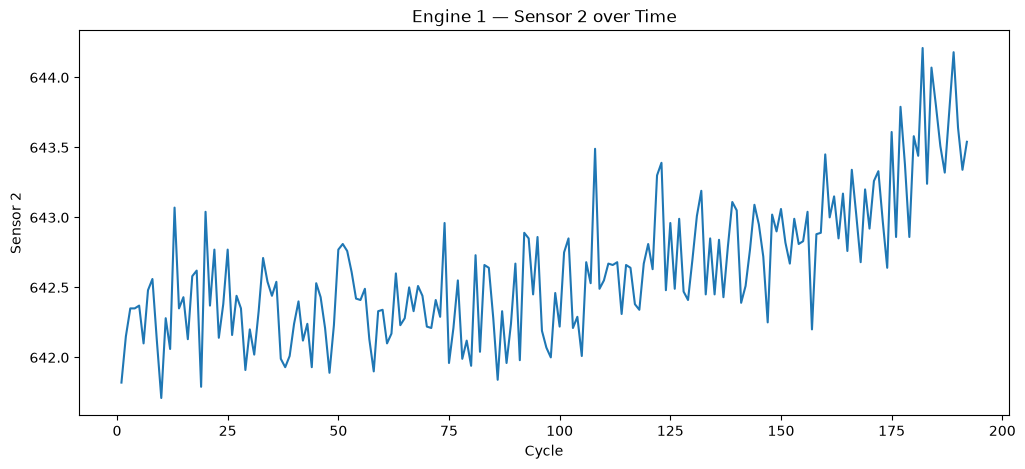

In [26]:
plt.figure(figsize=(12, 5))

plt.plot(
    engine_1["cycle"],
    engine_1["sensor_2"]
)

plt.xlabel("Cycle")
plt.ylabel("Sensor 2")
plt.title("Engine 1 — Sensor 2 over Time")
plt.show()

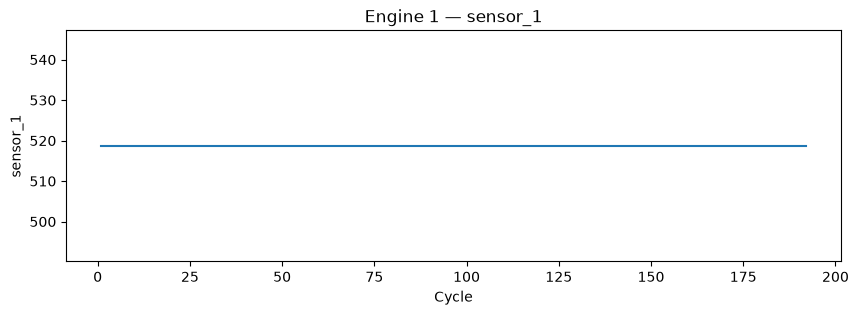

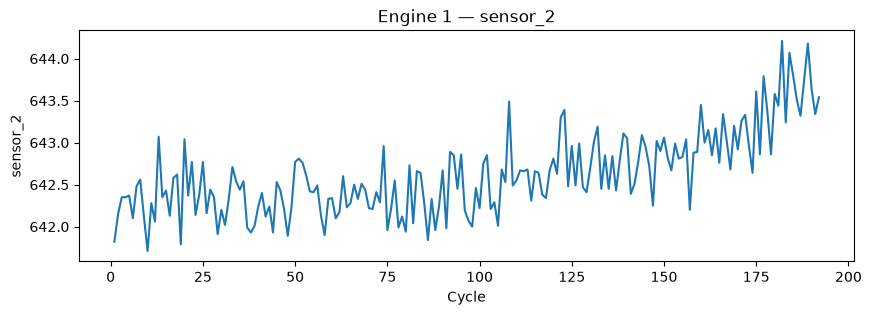

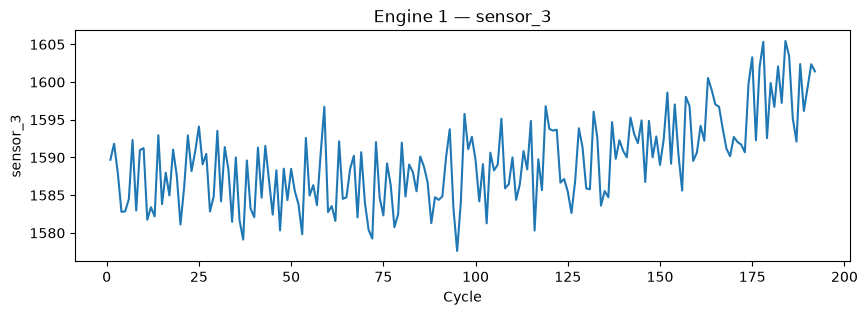

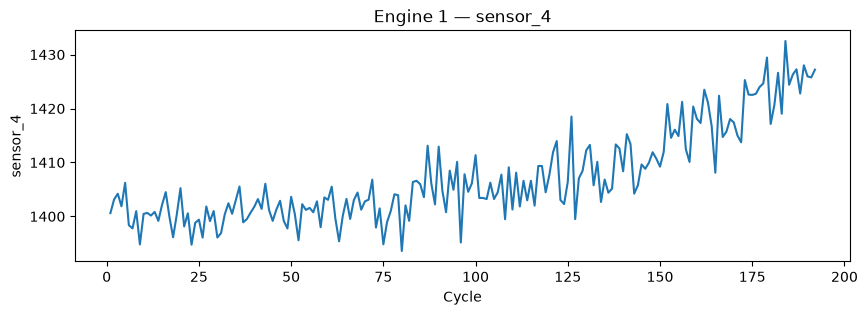

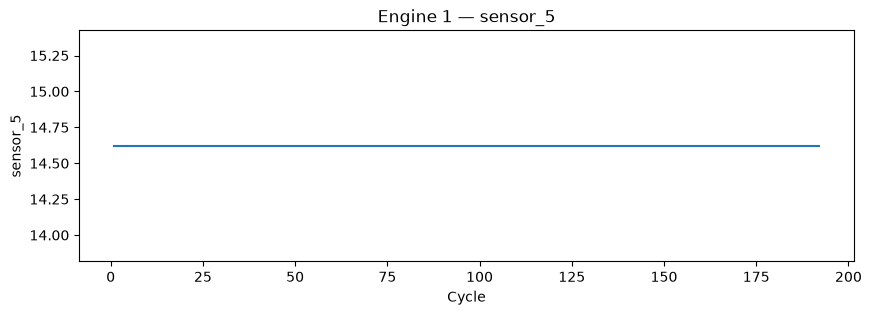

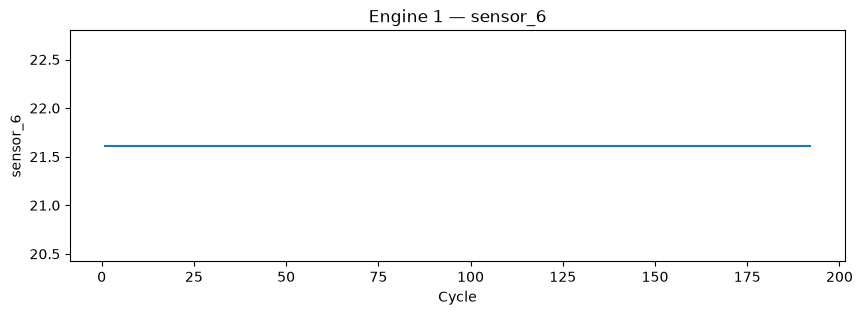

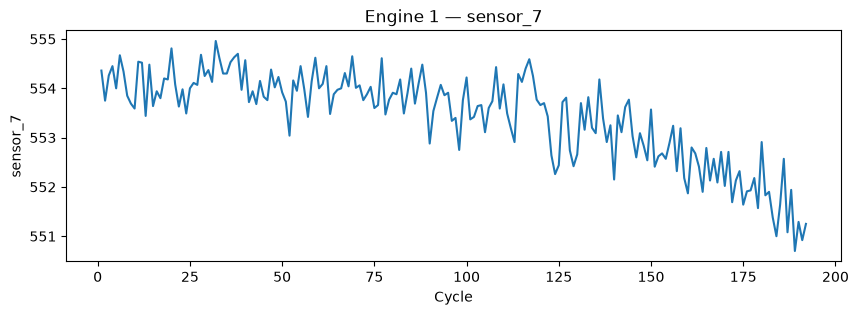

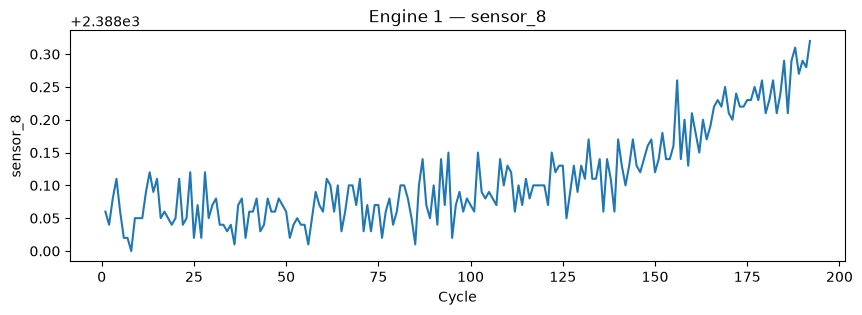

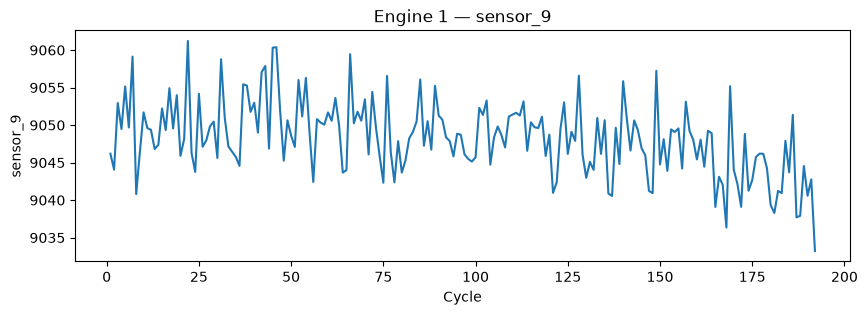

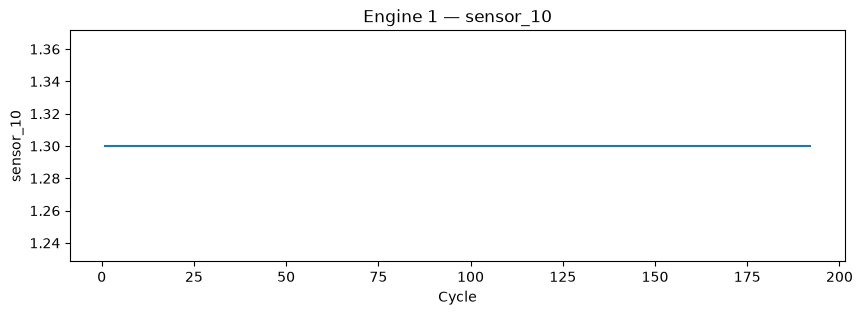

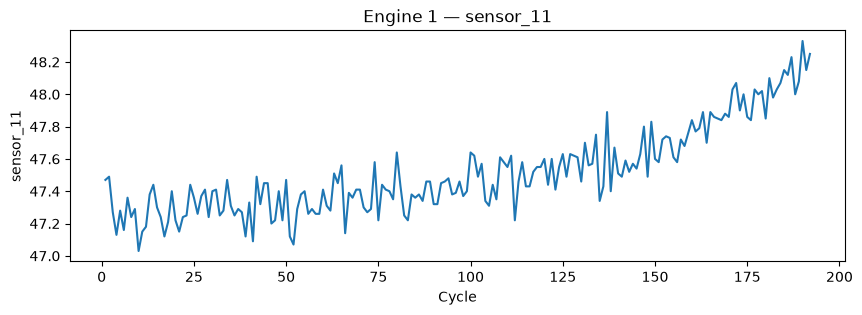

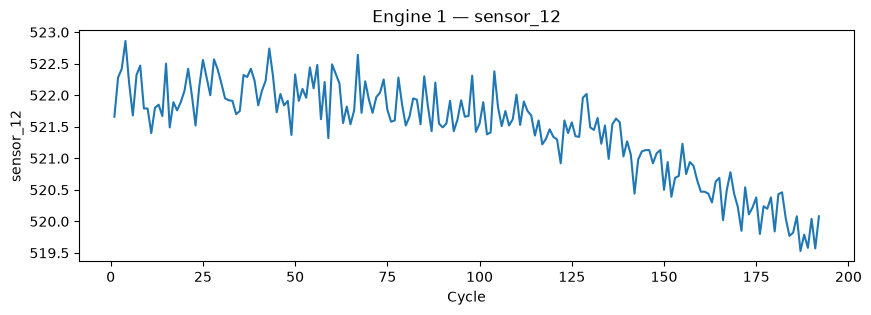

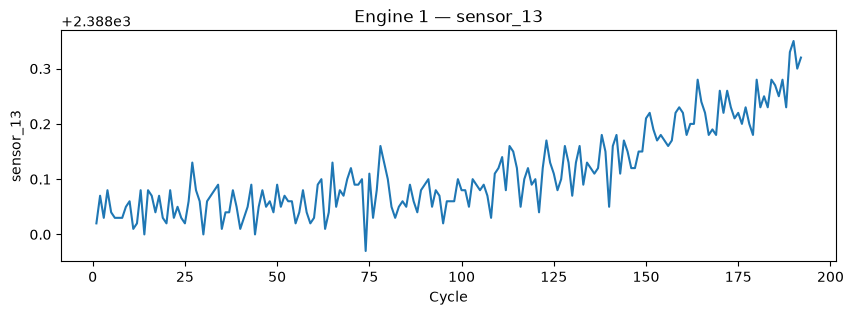

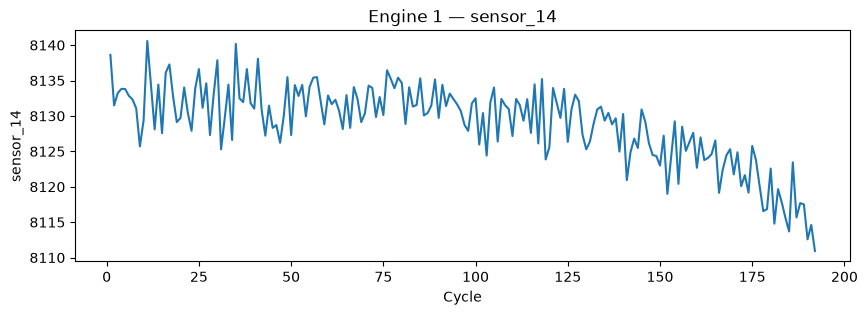

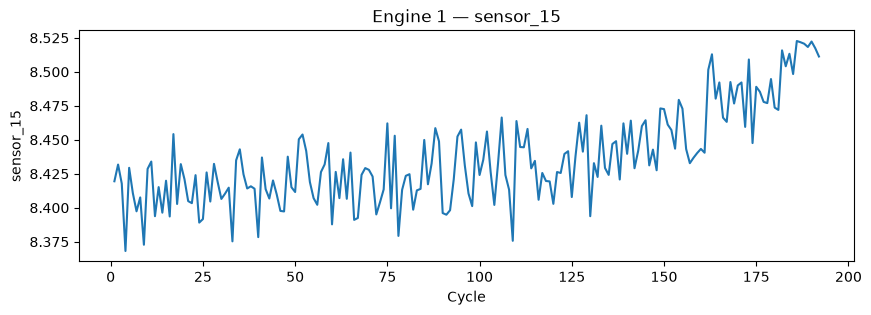

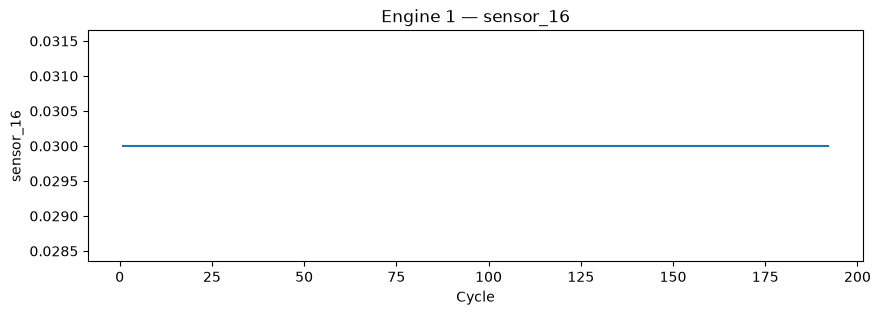

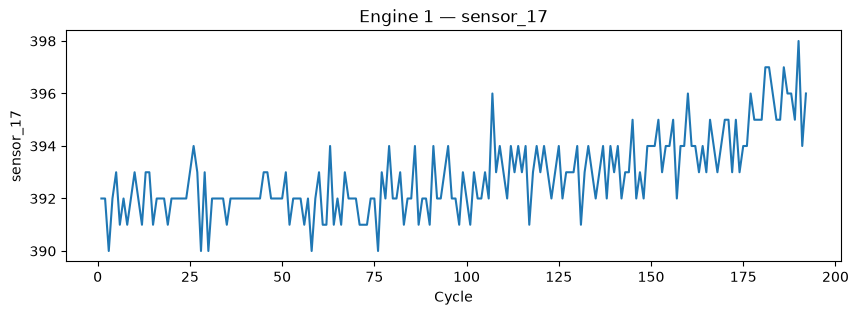

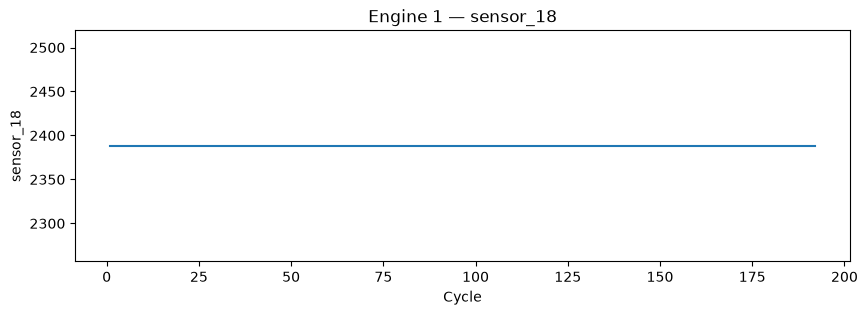

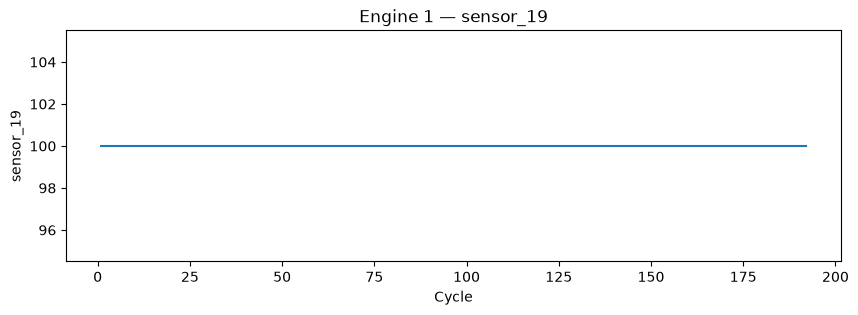

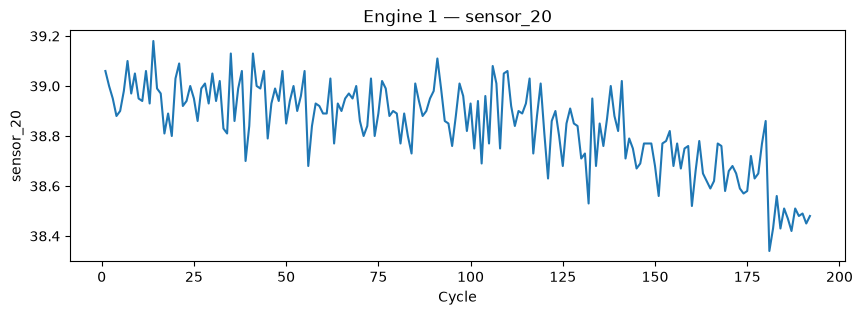

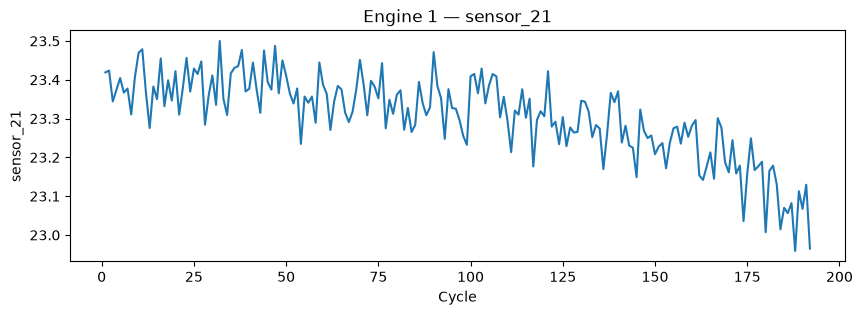

In [27]:
for sensor in sensor_cols:
    plt.figure(figsize=(10, 3))
    plt.plot(engine_1["cycle"], engine_1[sensor])
    plt.title(f"Engine 1 — {sensor}")
    plt.xlabel("Cycle")
    plt.ylabel(sensor)
    plt.show()

In [28]:
train_df["RUL"] = (
    train_df.groupby("engine_id")["cycle"]
    .transform("max")
    - train_df["cycle"]
)

In [29]:
train_df[
    train_df["engine_id"] == 1
][["engine_id", "cycle", "RUL"]].tail(10)

,engine_id,cycle,RUL
182,1,183,9
183,1,184,8
184,1,185,7
185,1,186,6
186,1,187,5
187,1,188,4
188,1,189,3
189,1,190,2
190,1,191,1
191,1,192,0


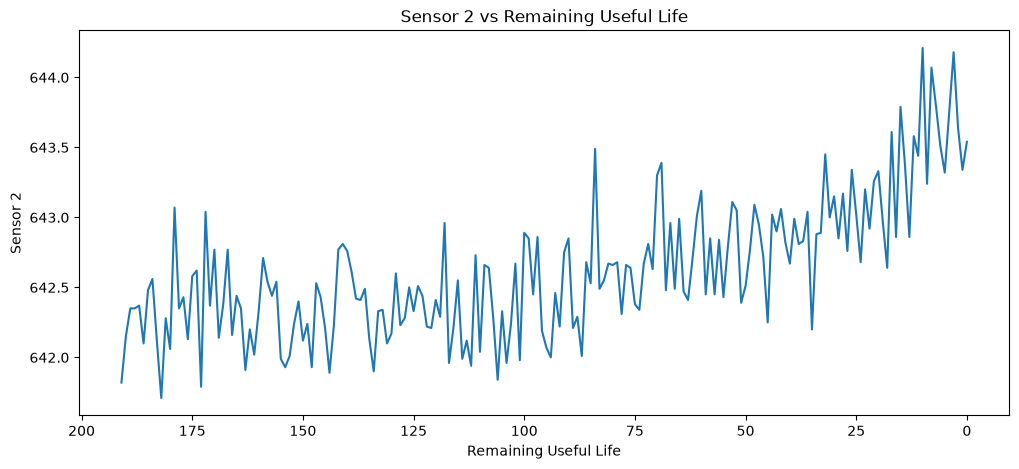

In [30]:
engine_1 = train_df[train_df["engine_id"] == 1]

plt.figure(figsize=(12, 5))

plt.plot(
    engine_1["RUL"],
    engine_1["sensor_2"]
)

plt.xlabel("Remaining Useful Life")
plt.ylabel("Sensor 2")
plt.title("Sensor 2 vs Remaining Useful Life")
plt.gca().invert_xaxis()

plt.show()